In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import math

ottimizzazione (trovare i valori che danno il massimo o il minimo di una funzione)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 10.0
        x: [-9.442e-09]
      nit: 2
      jac: [ 0.000e+00]
 hess_inv: [[ 5.000e-01]]
     nfev: 6
     njev: 3


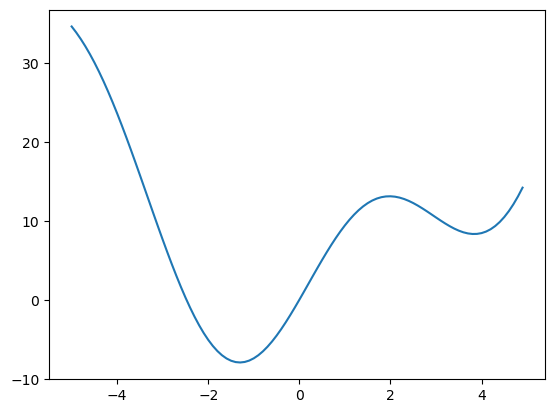

In [12]:
#ottimizzazione di uno scalare

def f(x):
    return x**2 + 10 * np.sin(x)
from scipy import optimize as spp
import scipy as sp
x = np.arange(-5,5,0.1)

plt.plot(x,f(x))
plt.grid=True

res=spp.minimize_scalar(f)
res

#funzioni con più variabili: minimaze

def f(x):
    return x**2 +10

#x0 sarebbe il punto di partenza
res= spp.minimize(f,x0=1)
print(res)


In [13]:
#integrazione

integrale, stima_corrente=sp.integrate.quad(np.sin,0,np.pi/2)
print(integrale)

0.9999999999999999


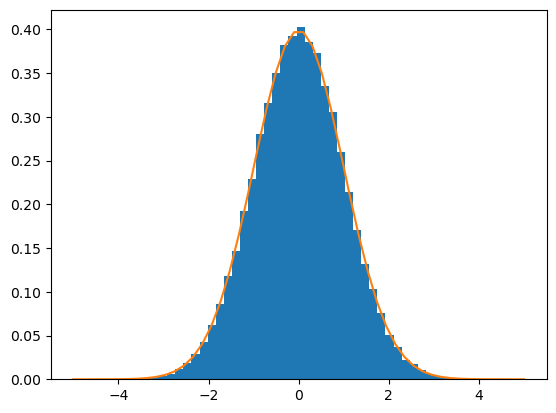

In [23]:
dist= sp.stats.norm(loc=0, scale=1) #una distribuzione normale
sample= dist.rvs(size = 100000) #faccio un cambianmento di 100000 valori
plt.hist(sample, bins=50, density=True)
x = np.linspace(-5,5)
plt.plot(x, dist.pdf(x), label='PDF')


In [21]:
#posso usare fit per trovare  la media e la varianza perfetti per un mio campionamento

loc, scale = sp.stats.norm.fit(sample)
loc,scale

(-0.0008226475768157485, 1.0043432303676243)

TypeError: 'bool' object is not callable

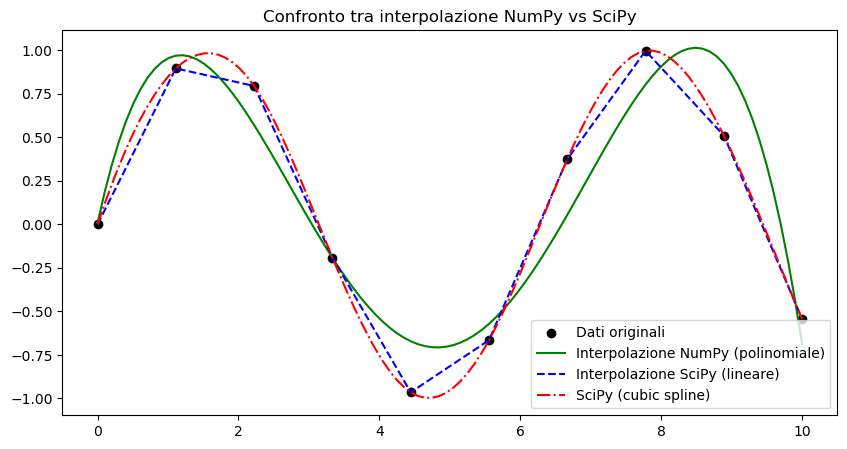

In [ ]:
#interpolazione: trovare una funzione che passa su un insieme di punti, alla fineè una retta che va in ogni punto
# Interpolazione
# Dati 
x = np.linspace(0, 10, 10)
y = np.sin(x)
x_interp = np.linspace(0, 10, 100)  # Punti dove interpolare

# Interpolazione polinomiale 
coeffs = np.polyfit(x, y, deg=4)
y_np_interp = np.polyval(coeffs, x_interp)
from scipy.interpolate import interp1d

# Interpolazione lineare
f_linear = interp1d(x, y, kind='linear')
y_scipy_interp = f_linear(x_interp)

# Interpolazione spline cubica con SciPy
f_cubic = interp1d(x, y, kind='cubic')
y_cubic = f_cubic(x_interp)


plt.figure(figsize=(10, 5))
plt.scatter(x, y, label="Dati originali", color='black')
plt.plot(x_interp, y_np_interp, label="Interpolazione NumPy (polinomiale)", color='green')
plt.plot(x_interp, y_scipy_interp, label="Interpolazione SciPy (lineare)", linestyle='--', color='blue')
plt.plot(x_interp, y_cubic, label="SciPy (cubic spline)", linestyle='-.', color='red')
plt.legend()
plt.title("Confronto tra interpolazione NumPy vs SciPy")
plt.grid(True)
plt.show()


TypeError: 'bool' object is not callable

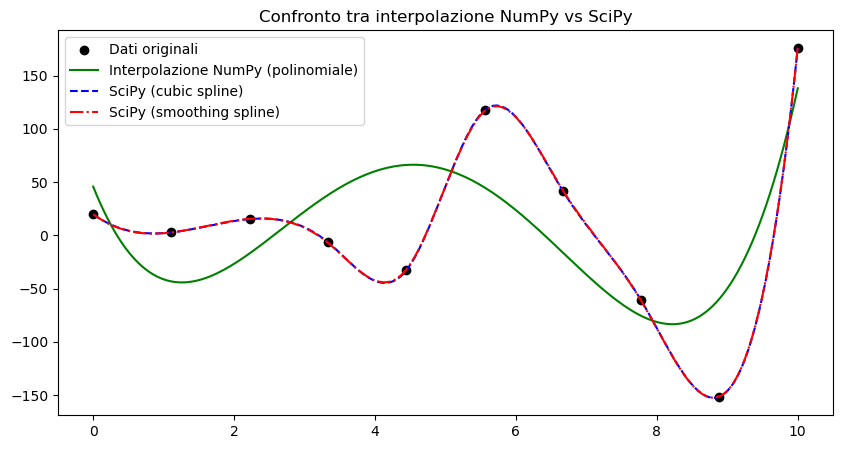

In [29]:
# Dati 
x = np.linspace(0, 10, 10)
y = np.sin(x) + np.random.normal(scale=100, size=len(x)) #qui aggiungo un "rumore"
x_interp = np.linspace(0, 10, 200)  # Punti dove interpolare


# Interpolazione polinomiale 
coeffs = np.polyfit(x, y, deg=4)
y_np_interp = np.polyval(coeffs, x_interp)


# Interpolazione spline cubica con SciPy
f_cubic = sp.interpolate.interp1d(x, y, kind='cubic')
y_cubic = f_cubic(x_interp)

# Smoothing spline con SciPy
spline = sp.interpolate.UnivariateSpline(x, y, s=2)  # Il parametro s controlla la "levigatezza"
y_smooth = spline(x_interp)
plt.figure(figsize=(10, 5))
plt.scatter(x, y, label="Dati originali", color='black')
plt.plot(x_interp, y_np_interp, label="Interpolazione NumPy (polinomiale)", color='green')
plt.plot(x_interp, y_cubic, label="SciPy (cubic spline)", linestyle='--', color='blue')
plt.plot(x_interp, y_smooth, label="SciPy (smoothing spline)", linestyle='-.', color='red')
plt.legend()
plt.title("Confronto tra interpolazione NumPy vs SciPy")
plt.grid(True)
plt.show()

PARTE DUE: REGRESSIONE

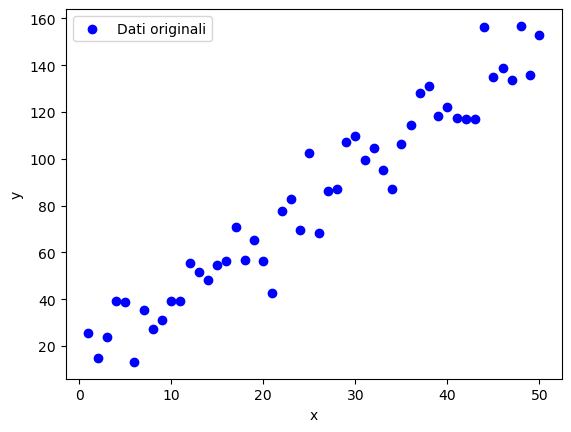

In [30]:
#regressione lineare condidero delle variabili lineari, qui devo stimare i coefficenti andando a minimaazare la somma dei quiadrati residui

# Generazione dataset 
np.random.seed(0)

# ESEMPIO: dati quasi lineari con rumore
x = np.linspace(1, 50, 50)
y_true = 3 * x + 5 
y = y_true + np.random.normal(0, 10, size=len(x))  # y = 3x + 5 + rumore

# Plot
plt.scatter(x, y, label="Dati originali", color="blue")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()



In [32]:
# --- Calcoliamo "a mano" la retta di regressione lineare ---

def fit_line(x, y):
    """
    Calcola il fitting lineare dei dati su una retta y = mx + q.
    """
    if len(x) != len(y):
        raise ValueError("Le liste x e y devono avere la stessa lunghezza.")
    if len(x) < 2:
        raise ValueError("Sono necessari almeno due punti per calcolare una retta.")
    
    N = len(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x[i] * y[i] for i in range(N))
    sum_x_squared = sum(x[i] ** 2 for i in range(N))

    m = (N * sum_xy - sum_x * sum_y) / (N * sum_x_squared - sum_x ** 2)
    q = (sum_y - m * sum_x) / N
    return m, q

def predict(x_val, m, q):
    """
    Predice il valore y usando una retta y = mx + q.
    """
    return m * x_val + q

Coefficiente angolare (m): 2.711913776940778
Intercetta (q): 13.751791411141157


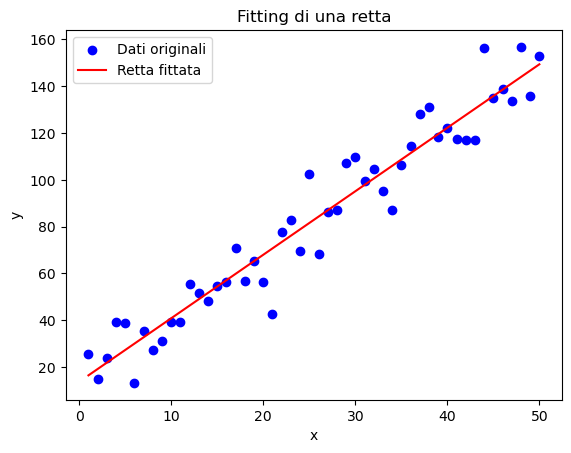

In [33]:
# Fitting della retta
m, q = fit_line(x, y) 

# Predizione dei valori fittati
retta_pred = [predict(i, m, q) for i in x]

# Output dei parametri della retta
print(f"Coefficiente angolare (m): {m}")
print(f"Intercetta (q): {q}")

# Plot
plt.scatter(x, y, label="Dati originali", color="blue")
plt.plot(x, retta_pred, label="Retta fittata", color="red")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitting di una retta")
plt.show()

Coefficiente angolare (m): 1.0383927637865593
Intercetta (q): -4.838893183706744
Intercetta (q): 104.48751570507036


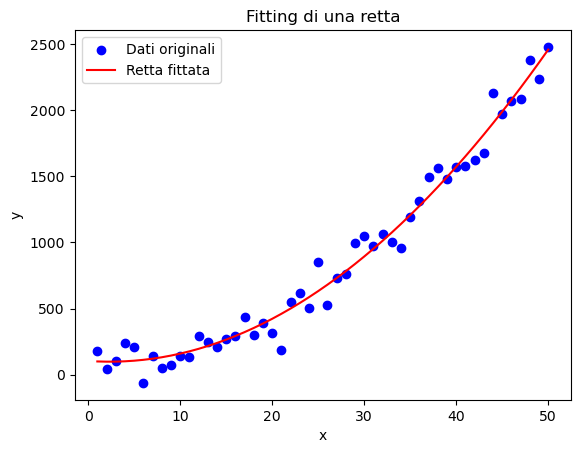

In [35]:
# Generazione dataset quadratico
np.random.seed(0)

# ESEMPIO 1: dati quadratici lineari con rumore
x = np.linspace(1, 50, 50)
y = x**2 + np.random.normal(0, 100, size=x.shape)  # y = x2 + rumore

# Fitting della retta
a, b, c = np.polyfit(x, y, 2)  # Grado 2 per una retta

# Predizione dei valori fittati
y_fit_q_np = a * x**2  + b * x + c

# Output dei parametri della retta
print(f"Coefficiente angolare (m): {a}")
print(f"Intercetta (q): {b}")
print(f"Intercetta (q): {c}")

# Plot
plt.scatter(x, y, label="Dati originali", color="blue")
plt.plot(x, y_fit_q_np, label="Retta fittata", color="red")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitting di una retta")
plt.show()

Parametro a (x²): 1.0383927637866435
Parametro b (x): -4.8388931837195
Parametro c (intercetta): 104.48751570529649


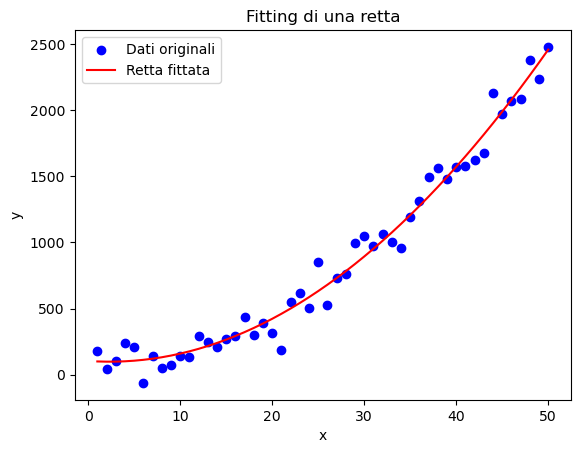

In [36]:
# Generazione di due dataset realistici: uno quasi lineare, uno quasi quadratico
np.random.seed(0)

# ESEMPIO 1: dati quadratici con rumore
x = np.linspace(1, 50, 50)
y = x**2 + np.random.normal(0, 100, size=x.shape)  # y = x2 + rumore

# Definizione del modello quadratico
def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

# Fit con SciPy
params, _ = sp.optimize.curve_fit(quadratic, x, y)
a, b, c = params

# Predizioni
y_fit_q_sp = quadratic(x, a, b, c)
# Output dei parametri
print(f"Parametro a (x²): {a}")
print(f"Parametro b (x): {b}")
print(f"Parametro c (intercetta): {c}")

# Plot
plt.scatter(x, y, label="Dati originali", color="blue")
plt.plot(x, y_fit_q_sp, label="Retta fittata", color="red")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitting di una retta")
plt.show()

TypeError: 'bool' object is not callable

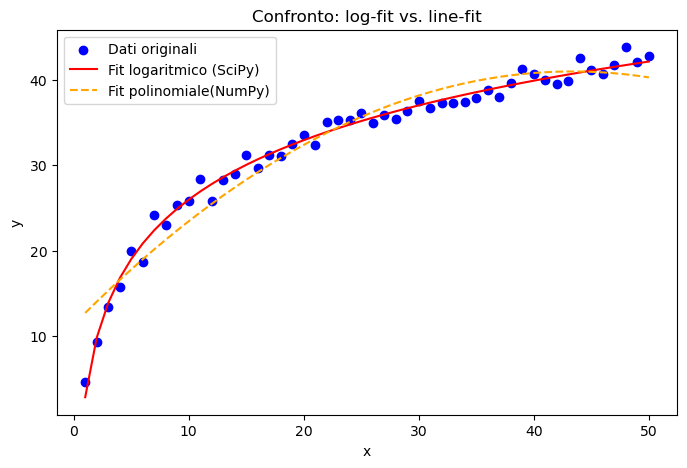

In [37]:
# Generazione dati logaritmici + rumore
np.random.seed(1)
x = np.linspace(1, 50, 50)
y = 10 * np.log(x) + 3 + np.random.normal(0, 1, size=x.shape)  # y = 10*log(x) + 3 + rumore

# Definizione del modello logaritmico
def log_model(x, a, b):
    return a * np.log(x) + b

# Fit con SciPy
params, _ = sp.optimize.curve_fit(log_model, x, y)
a, b = params

# Predizione
y_fit = log_model(x, a, b)

# Proviamo a fittare con numpy usando un finto modello lineare su x, non su log(x)
coeffs_poly = np.polyfit(x, y, 2) 
y_polyfit = np.polyval(coeffs_poly, x)

# Plot confronto
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Dati originali", color="blue")
plt.plot(x, y_fit, label="Fit logaritmico (SciPy)", color="red")
plt.plot(x, y_polyfit, label="Fit polinomiale(NumPy)", color="orange", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Confronto: log-fit vs. line-fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [44]:
from model_optimise import TrendModel, FitTrendModel
from importa_dati import NumericalCSVFile
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

In [ ]:
#PRIMA FACEVAMO COSI

# Creo un'istanza della classe NumericalCSVFile con il nome del file 'shampoo_sales.csv'
shampoofile = NumericalCSVFile('../shampoo_sales.csv')

# Chiamo il metodo get_data per ottenere i dati numerici
lista_dati = shampoofile.get_data()

# Separiamo le date e i valori in due liste
dates = [item[0] for item in lista_dati]
values = [item[1] for item in lista_dati]

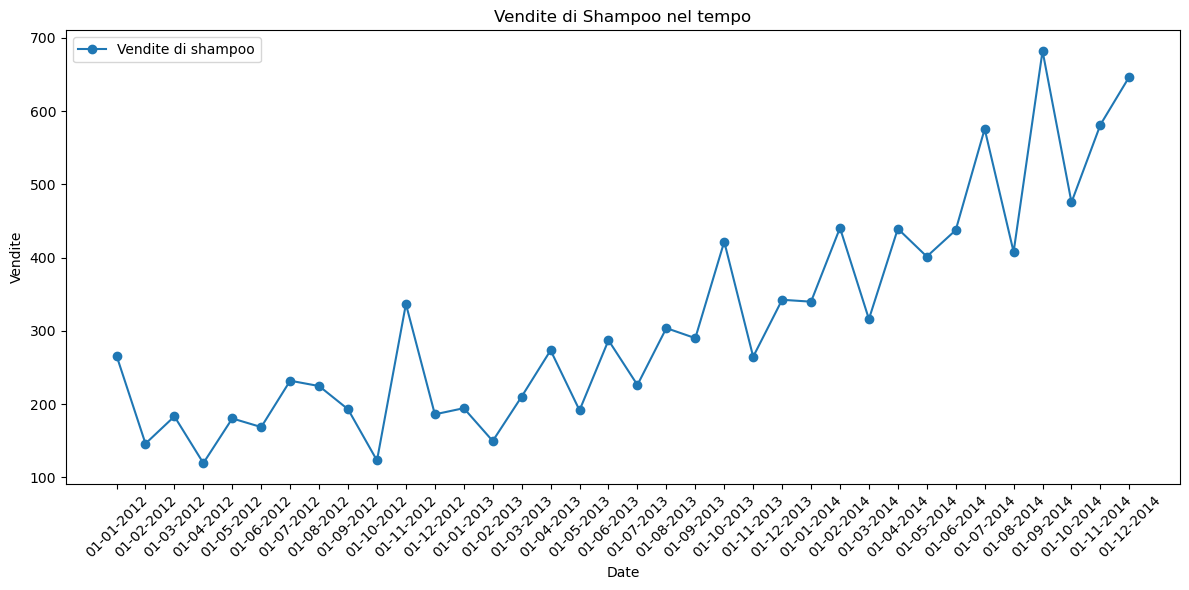

In [49]:
# Plot dei dati
plt.figure(figsize=(12, 6))
plt.plot(dates, values, marker='o', linestyle='-', label='Vendite di shampoo')
plt.title('Vendite di Shampoo nel tempo')
plt.xlabel('Date')
plt.ylabel('Vendite')
plt.xticks(rotation=45)  # Ruota le etichette delle date per una migliore leggibilità
plt.legend()
plt.grid=True
plt.tight_layout()  # Migliora la disposizione degli elementi nel grafico
plt.show()

TypeError: 'bool' object is not callable

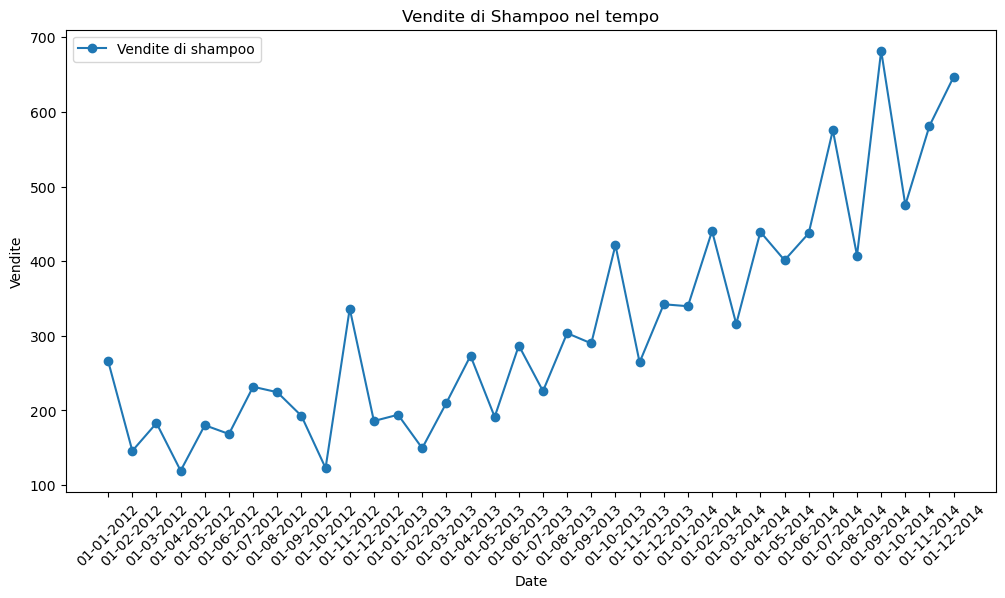

In [51]:
#ORA POSSIAMO FARE COSI
# Carica il file CSV
df = pd.read_csv("../shampoo_sales.csv")

dates = df['Date'].values
values = df['Sales'].values

# Plot dei dati
plt.figure(figsize=(12, 6))
plt.plot(df['Date'].values, values, marker='o', linestyle='-', label='Vendite di shampoo')
plt.title('Vendite di Shampoo nel tempo')
plt.xlabel('Date')
plt.ylabel('Vendite')
plt.xticks(rotation=45)  # Ruota le etichette delle date per una migliore leggibilità
plt.legend()
plt.grid(True)
plt.tight_layout()  # Migliora la disposizione degli elementi nel grafico
plt.show()

In [54]:
# --- PREPARAZIONE DATI ---
# Creo un'istanza della classe NumericalCSVFile con il nome del file 'shampoo_sales.csv'
shampoofile = NumericalCSVFile('../shampoo_sales.csv')

# Chiamo il metodo get_data per ottenere i dati numerici
lista_dati = shampoofile.get_data()

# Separiamo le date e i valori in due liste
dates = [item[0] for item in lista_dati]
values = [item[1] for item in lista_dati]

# Dati usati per addestrare il modello FitTrendModel (fino alla 24° osservazione)
fit_values = values[:24]
# Dati di test (dal 25° elemento in poi)
test_values = values[24:]
# Dati da cui iniziare a prevedere per TrendModel (ultimi 3 del fit + test)
data = values[21:]
window = 2  # Finestra mobile per il modello

TypeError: 'bool' object is not callable

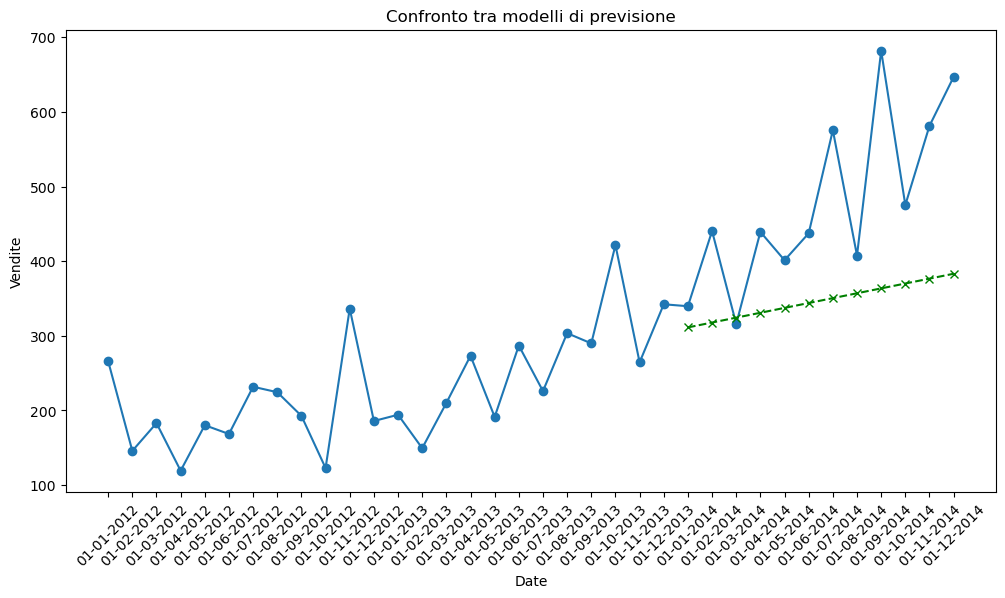

In [55]:
# --- Fitting della retta ---

x_fit = list(range(1, 25))
m, q = fit_line(x_fit, fit_values)

# Predizioni sulla parte di test (dal punto 25 in poi)
x_test = list(range(25, 1 + len(values)))
retta_pred = [predict(i, m, q) for i in range(25, 1 + len(values))]


# --- PLOT ---
x = list(range(len(values)))

plt.figure(figsize=(12, 6))
plt.plot(dates, values, marker='o', label='Dati reali')
plt.plot(dates[24:], retta_pred, color='green', linestyle='--', marker='x', label='Modello Lineare')
plt.title('Confronto tra modelli di previsione')
plt.xlabel('Date')
plt.ylabel('Vendite')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
# --- VALUTAZIONE MAE (già fornito da Model.evaluate) ---
mae_trend = trend_model.evaluate(values)
mae_fit_trend = fit_trend_model.evaluate(values)

print(f"TrendModel → MAE: {mae_trend:.2f}")
print(f"FitTrendModel → MAE: {mae_fit_trend:.2f}")

TrendModel → MAE: 240.88
FitTrendModel → MAE: 179.67


In [65]:

# --- VALUTAZIONE RMSE (già fornito da Model.evaluate) ---
rmse_trend = trend_model.evaluate_rmse(values)
rmse_fit_trend = fit_trend_model.evaluate_rmse(values)


print(f"TrendModel → MAE: {mae_trend:.2f}, RMSE: {rmse_trend:.2f}")
print(f"FitTrendModel → MAE: {mae_fit_trend:.2f}, RMSE: {rmse_fit_trend:.2f}")

TrendModel → MAE: 240.88, RMSE: 283.54
FitTrendModel → MAE: 179.67, RMSE: 212.89


In [66]:
# --- Calcolo errori --- Modello lineare (solo su test)
mae_line = calculate_mae(test_values, retta_pred)
rmse_line = calculate_rmse(test_values, retta_pred)

# --- STAMPA RISULTATI ---
print(f"TrendModel      → MAE: {mae_trend:.2f}, RMSE: {rmse_trend:.2f}")
print(f"FitTrendModel   → MAE: {mae_fit_trend:.2f}, RMSE: {rmse_fit_trend:.2f}")
print(f"Modello Lineare → MAE: {mae_line:.2f}, RMSE: {rmse_line:.2f}")

TrendModel      → MAE: 240.88, RMSE: 283.54
FitTrendModel   → MAE: 179.67, RMSE: 212.89
Modello Lineare → MAE: 132.71, RMSE: 162.65


In [58]:
# --- MODELLO TREND SEMPLICE (senza fit) ---

trend_model = TrendModel(window=2)
pred_data = [values[23]]  # primo punto noto da cui parte la previsione
# Ciclo di previsione per TrendModel
for i, item in enumerate(data[:]):
    if i >= window:
        prediction = trend_model.predict(data[i-window:i])
        pred_data.append(prediction)

In [61]:
# --- MODELLO FITTREND (con fit) ---

fit_trend_model = FitTrendModel(window=2)
fit_pred_data = []

# Prime due osservazioni reali passate al modello per iniziare a predire
predicted_values = data[:window]
# Fase di "fit" con i dati storici
fit_trend_model.fit(fit_values)
# Previsioni passo-passo su test_values
for i in range(len(test_values) - window):
    prediction = fit_trend_model.predict(predicted_values)
    fit_pred_data.append(prediction)
    del predicted_values[0]  # rimuove il più vecchio
    predicted_values.append(test_values[i + window])  # aggiunge il nuovo valore reale

TypeError: 'bool' object is not callable

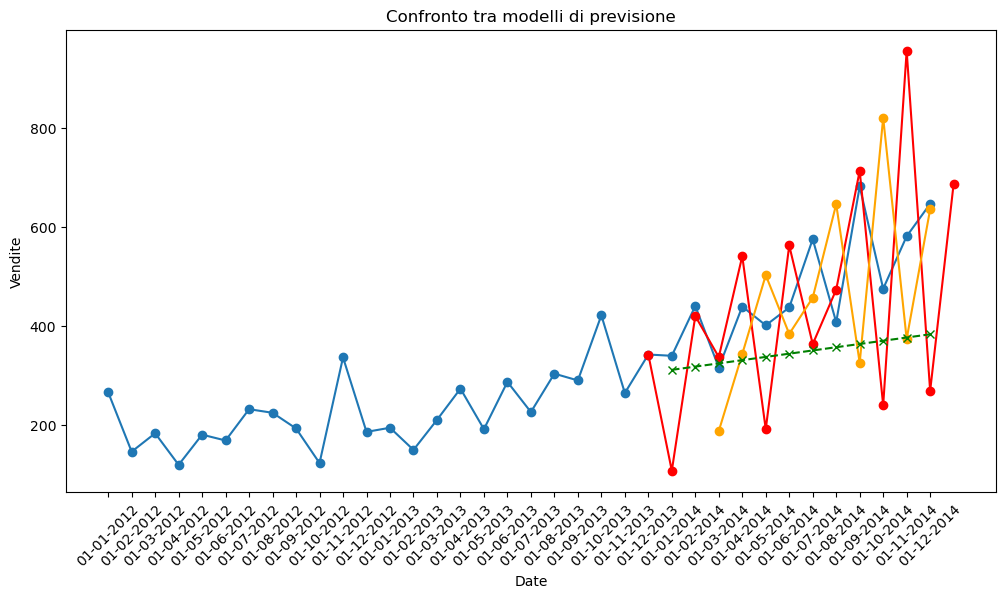

In [62]:
# --- PLOT COMPLETO ---
x = list(range(len(values)))
x_pred = list(range(23, 23 + len(pred_data)))
x_fit = list(range(26, 26 + len(fit_pred_data)))

plt.figure(figsize=(12, 6))
plt.plot(dates, values, marker='o', label='Dati reali')
plt.plot(x_pred, pred_data, color='red', marker='o', linestyle='-', label='Previsioni senza fit (TrendModel)')
plt.plot(x_fit, fit_pred_data, color='orange', marker='o', linestyle='-', label='Previsioni con fit (FitTrendModel)')
plt.plot(dates[24:], retta_pred, color='green', linestyle='--', marker='x', label='Modello Lineare')
plt.title('Confronto tra modelli di previsione')
plt.xlabel('Date')
plt.ylabel('Vendite')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
# --- POLINOMIO DI GRADO 2 (fit su fit_values, predizione su test_values) ---
x_fit = np.arange(1, 25)  # 1...24
coeffs = np.polyfit(x_fit, fit_values, deg=2)  # grado 2
poly = np.poly1d(coeffs)

x_test = np.arange(25, len(values) + 1)  # 25...36
poly_pred = poly(x_test)

# Polinomio grado 2
mae_poly = calculate_mae(test_values, poly_pred)
rmse_poly = calculate_rmse(test_values, poly_pred)

# --- STAMPA RISULTATI ---
print(f"TrendModel      → MAE: {mae_trend:.2f}, RMSE: {rmse_trend:.2f}")
print(f"FitTrendModel   → MAE: {mae_fit_trend:.2f}, RMSE: {rmse_fit_trend:.2f}")
print(f"Modello Lineare → MAE: {mae_line:.2f}, RMSE: {rmse_line:.2f}")
print(f"Polinomio grado 2 → MAE: {mae_poly:.2f}, RMSE: {rmse_poly:.2f}")

TrendModel      → MAE: 240.88, RMSE: 283.54
FitTrendModel   → MAE: 179.67, RMSE: 212.89
Modello Lineare → MAE: 132.71, RMSE: 162.65
Polinomio grado 2 → MAE: 61.62, RMSE: 73.91


TypeError: 'bool' object is not callable

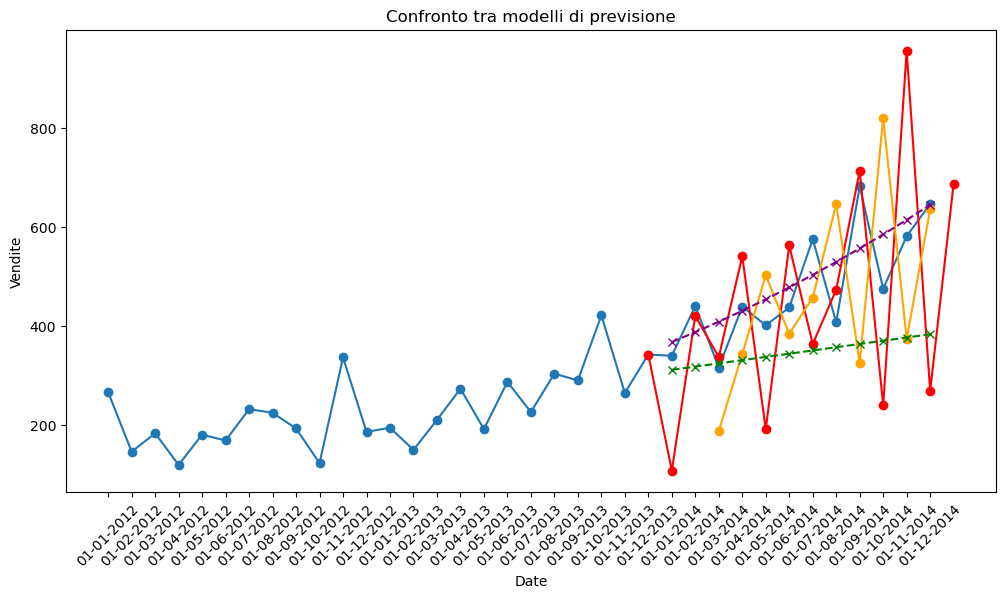

In [68]:
# --- PLOT COMPLETO ---
x = list(range(len(values)))
x_pred = list(range(23, 23 + len(pred_data)))
x_fit = list(range(26, 26 + len(fit_pred_data)))

plt.figure(figsize=(12, 6))
plt.plot(dates, values, marker='o', label='Dati reali')
plt.plot(x_pred, pred_data, color='red', marker='o', linestyle='-', label='Previsioni senza fit (TrendModel)')
plt.plot(x_fit, fit_pred_data, color='orange', marker='o', linestyle='-', label='Previsioni con fit (FitTrendModel)')
plt.plot(dates[24:], retta_pred, color='green', linestyle='--', marker='x', label='Modello Lineare')
plt.plot(dates[24:], poly_pred, color='purple', linestyle='--', marker='x', label='Polinomio grado 2')
plt.title('Confronto tra modelli di previsione')
plt.xlabel('Date')
plt.ylabel('Vendite')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()